![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Final Project - Design

#### By: Sergi Nàcher Muñoz

## 0. Imports 

### 0.1. General libraries

In [152]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td

import gdsfactory as gf
import jax
import jax.example_libraries.optimizers as opt
import jax.numpy as jnp
from matplotlib.pyplot import cm

import sax
from gdsfactory.generic_tech import get_generic_pdk
from scipy import constants
from scipy.constants import c
from scipy.interpolate import interp1d

import gplugins.sax as gs
import gplugins as gp
import gplugins.tidy3d as gt
from gplugins import plot
from gplugins.common.config import PATH

from upvfab.sin300.cband import PDK, cells

In [153]:
import matplotlib.pyplot as plt
import numpy as np
import gplugins.tidy3d as gt
import gdsfactory as gf

from upvfab.sin300.cband import PDK, cells

In [154]:
nm = 1e-3
wavelength = np.linspace(1500, 1600,11) * nm
f = td.C_0 / wavelength

### 0.2. Materials

In [155]:
si_complex = td.material_library["cSi"]["Li1993_293K"].eps_model(f)
si_index , si_k = td.Medium.eps_complex_to_nk(si_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

## Part I. Design and Simulation of Individual Components 

## 1. Simulating Propagation Modes in SOI Waveguides

### 1.1. Define the SOI waveguide structure (450 nm width, 220 nm thickness). 

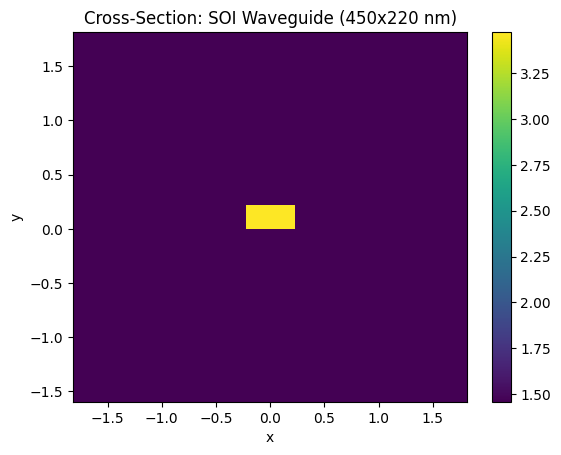

In [156]:
deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width = 0.45, # Waveguide width
    core_thickness = 0.22, # Waveguide height 
    slab_thickness = 0,  # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material = 'si', #  Material of the waveguide
    clad_material = 'sio2', # Surrounding material
    # Modesolver Parameters
    wavelength = 1.55, # Wavelength to simulate
    num_modes = 4, # Targeted number of modes to find 
    max_grid_scaling = 1.5, # Parameters of the grid
    grid_resolution = 20, # Parameters of the grid
    cache_path = '.cache/', # Important! In order to save simulation time, set your cache Path!
    precision = 'double'
)

deep_waveguide.plot_index()
plt.title("Cross-Section: SOI Waveguide (450x220 nm)")
plt.show()

### 1.2. Simulate fundamental TE and TM modes. 

In [157]:
deep_waveguide.n_eff

2026-05-19 22:10:52.652 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_198a1ab0a96c4a6f.npz.


array([2.33508782+7.05715980e-05j, 1.7447082 +2.39341986e-04j,
       1.46251286+2.05632472e-04j, 1.43196857+2.18207211e-04j])

In [158]:
deep_waveguide.fraction_te

array([0.960726  , 0.06940437, 0.64309704, 0.99810644])

In [159]:
deep_waveguide.fraction_tm

array([0.039274  , 0.93059563, 0.35690296, 0.00189356])

Text(0.5, 1.0, 'Modo 0 - Campo Ex (Modo TE0)')

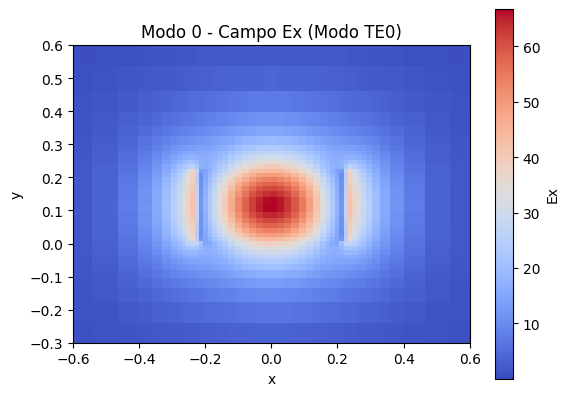

In [160]:
deep_waveguide.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                            cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-0.6, 0.6), # Set the x and y limits
                          ylim=(-0.3, 0.6)
) 

plt.title('Modo 0 - Campo Ex (Modo TE0)')

Text(0.5, 1.0, 'Modo 1 - Campo Ey (Modo TM0)')

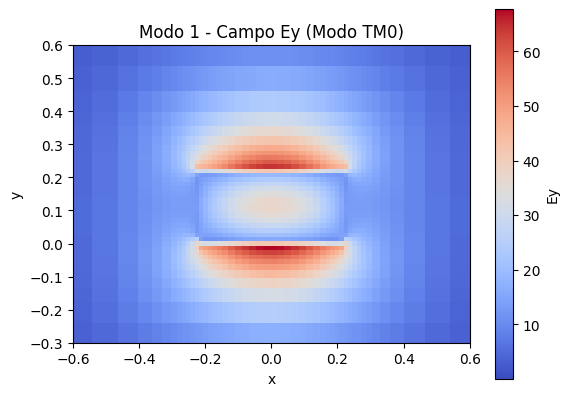

In [161]:
deep_waveguide.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                            cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-0.6, 0.6), # Set the x and y limits
                          ylim=(-0.3, 0.6)
) 

plt.title('Modo 1 - Campo Ey (Modo TM0)')

Para el modo fundamental TM0 se puede observar un campo poco confinado en el núcleo, y en su lugar la luz viaja por el cladding.

Ya tenemos los modos fundamentales tanto para TE como para TM. Ahora vamos a verificar que los demás modos están en corte

Text(0.5, 1.0, 'Modo 2 - Campo Ex')

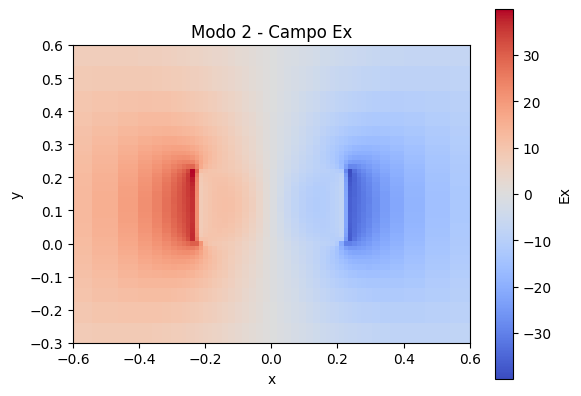

In [162]:
deep_waveguide.plot_field(mode_index=2 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                            cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-0.6, 0.6), # Set the x and y limits
                          ylim=(-0.3, 0.6)
) 

plt.title('Modo 2 - Campo Ex')

Text(0.5, 1.0, 'Modo 2 - Campo Ey')

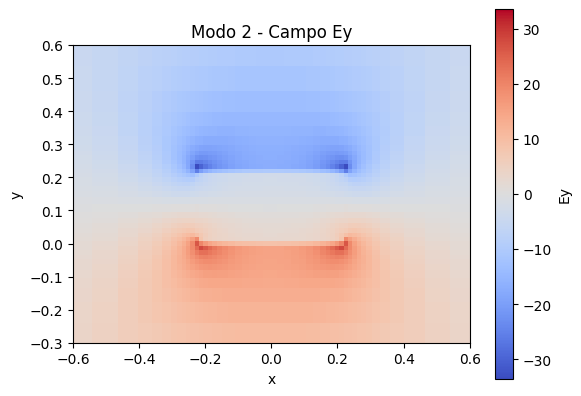

In [163]:
deep_waveguide.plot_field(mode_index=2 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                            cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-0.6, 0.6), # Set the x and y limits
                          ylim=(-0.3, 0.6)
) 

plt.title('Modo 2 - Campo Ey')

Por tanto, hemos verificado que los siguientes modos estarán en corte como ya se había previsto.

### 1.3. Extract effective index (n_eff) and group index (n_g) values. 

In [164]:
# 1. Cargamos el archivo con los barridos precalculados
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

# Extraemos las columnas que nos interesan: Longitud de onda (0) y n_eff del Modo TE (3)
wvl = SOI[:, 0]
neff_te = SOI[:, 3]

# 2. Buscamos el índice exacto para la longitud de onda central (1.55 um)
indice_central = np.where(np.isclose(wvl, 1.55))[0][0]

wvl_central = wvl[indice_central]
n_eff_TE = neff_te[indice_central]

# 3. Calculamos la derivada (dn_eff / d_lambda) usando los puntos anterior y posterior
dn_eff = (neff_te[indice_central + 1] - neff_te[indice_central - 1]) / 2
delta_wvl = (wvl[indice_central + 1] - wvl[indice_central - 1]) / 2

dn_eff_dlambda = dn_eff / delta_wvl

# 4. Aplicamos la fórmula del Índice de Grupo (n_g)
n_g_TE = n_eff_TE - (wvl_central * dn_eff_dlambda)

# Mostramos los resultados por pantalla
print("--- RESULTADOS MODO FUNDAMENTAL TE ---")
print(f"n_eff TE a 1.55um: {n_eff_TE:.4f}")
print(f"n_g TE calculado:  {n_g_TE:.4f}")

--- RESULTADOS MODO FUNDAMENTAL TE ---
n_eff TE a 1.55um: 2.3558
n_g TE calculado:  4.2933


## 2. Designing Directional Couplers

### 2.1. Simulate directional couplers in GDSFactory. 

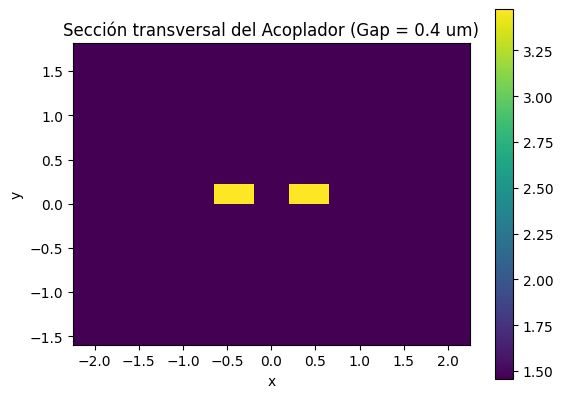

2026-05-19 22:10:52.985 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_e0ddedf4d2ad1493.npz.


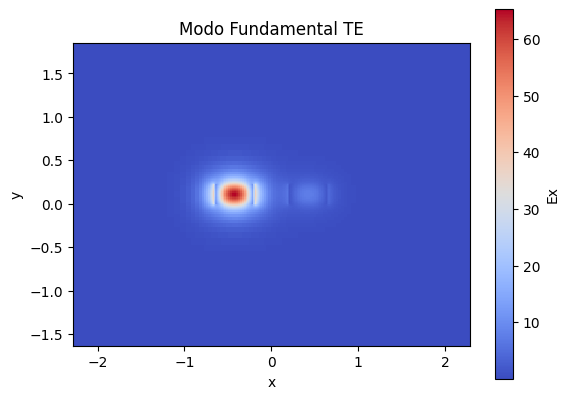

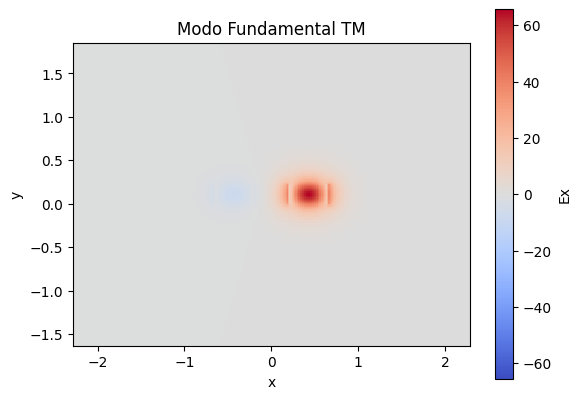

In [165]:
w = 0.45 # Waveguide width
h = 0.22 # Waveguide height 
wvl = 1.55 # Wavelength
gap = 0.4 # Gap entre los dos waveguides del acoplador

dcoupler_cs = gt.modes.WaveguideCoupler(
    core_width = (w, w), 
    slab_thickness = 0, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness = h, 
    gap = gap,
    core_material = 'si',
    clad_material = 'sio2', 
    wavelength = wvl, 
    num_modes = 2, # Number of modes to find
    cache_path = '.cache/', # Important! In order to save simulation time, set your cache Path!
    grid_resolution = 20 # Parameters of the grid
)

# Visualizamos el índice de refracción
dcoupler_cs.plot_index()
plt.title(f"Sección transversal del Acoplador (Gap = {gap} um)")
plt.show()

dcoupler_cs.plot_field(mode_index=0, field_name='Ex', value='real', cmap='coolwarm')
plt.title("Modo Fundamental TE")
plt.show()

dcoupler_cs.plot_field(mode_index=1, field_name='Ex', value='real', cmap='coolwarm')
plt.title("Modo Fundamental TM")
plt.show()

### 2.2. Sweep different gap values and coupling lengths.
### 2.3. Extract coupling coefficients (e.g., 0.5, 0.3, 0.23, etc.).

L_pi (100% acoplo) para Gap 0.4 um: 35.7108 um

--- LONGITUDES EXACTAS PARA SAX ---
 K = 0.5  --> L = 17.8554 um
 K = 0.3  --> L = 13.1776 um
 K = 0.23 --> L = 11.3712 um
 K = 0.17 --> L = 9.6618 um
 K = 0.05 --> L = 5.1269 um


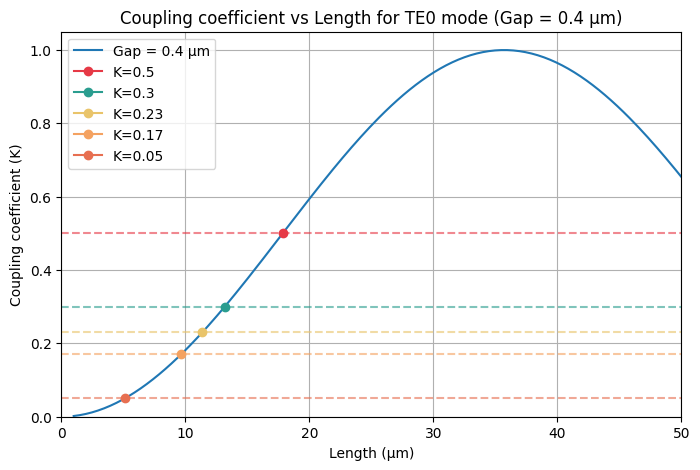

In [166]:
gap_fijo = 0.4
dcoupler_cs.gap = gap_fijo

# Cálculo de n_eff y L_pi
neff_even = dcoupler_cs.n_eff[0].real
neff_odd = dcoupler_cs.n_eff[1].real
L_pi_TE0 = 0.5 * wvl / (neff_even - neff_odd)

print(f"L_pi (100% acoplo) para Gap {gap_fijo} um: {L_pi_TE0:.4f} um\n")

# Barrido de Longitud L
length_values = np.linspace(1,50,200)

K_values = []
for length in length_values:
    K = np.sin(0.5 * np.pi * (length / L_pi_TE0))**2
    K_values.append(K)

# Gráfica
plt.figure(figsize=(8, 5))
plt.plot(length_values, K_values, label=f'Gap = {gap_fijo} µm')

objetivos = [0.5, 0.3, 0.23, 0.17, 0.05]
colores = ['#e63946', '#2a9d8f', '#e9c46a', '#f4a261', '#e76f51']

print("--- LONGITUDES EXACTAS PARA SAX ---")
for obj, col in zip(objetivos, colores):
    L_exacta = (2 * L_pi_TE0 / np.pi) * np.arcsin(np.sqrt(obj))
    print(f" K = {obj:<4} --> L = {L_exacta:.4f} um")
    plt.axhline(obj, color=col, linestyle='--', alpha=0.6)
    plt.plot(L_exacta, obj, marker='o', color=col, label=f'K={obj}')

plt.xlabel('Length (µm)')
plt.ylabel('Coupling coefficient (K)')
plt.title(f'Coupling coefficient vs Length for TE0 mode (Gap = {gap_fijo} µm)')
plt.xlim(0, max(length_values))
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.show()

2026-05-19 22:10:53.114 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_0c4d7ac9cfaffa37.npz.
2026-05-19 22:10:53.116 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_e5843c1a74c1c8a1.npz.
2026-05-19 22:10:53.118 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_042bf8448486c118.npz.
2026-05-19 22:10:53.119 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_74058f041f0e98c3.npz.
2026-05-19 22:10:53.120 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_89a2ac98e5d74980.npz.
2026-05-19 22:10:53.121 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_7e2e075e792c0f71.npz.
2026-05-19 22:10:53.122 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_67c7171084ceb275.npz.
2026-05-19 22:10:53.123 | INFO     | gplugins.tidy3d.modes:_data:266 - load 

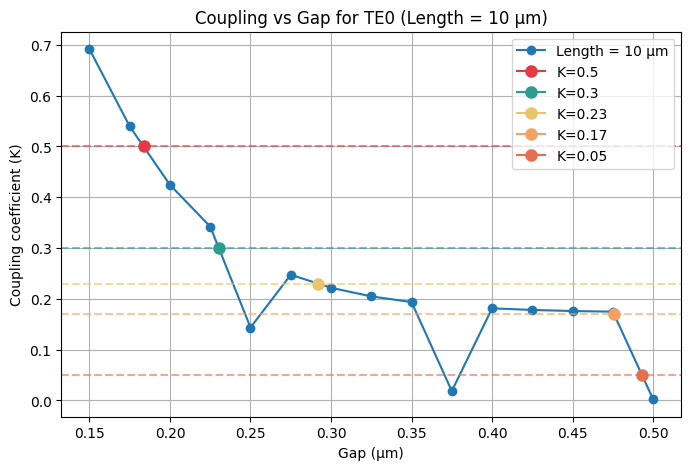

In [167]:
length = 10 # Longitud fija
wvl = 1.55 
gap_values = np.linspace(0.15, 0.5, 15) # Rango de gaps

K_values = []

for g in gap_values:

    dcoupler_cs = gt.modes.WaveguideCoupler(
    core_width = (w, w), 
    core_thickness = h, 
    gap = g,
    core_material = 'si',
    clad_material = 'sio2', 
    wavelength = wvl, 
    num_modes = 2,
    cache_path = '.cache/', 
    grid_resolution = 20 
)

    neff_even = dcoupler_cs.n_eff[0].real
    neff_odd = dcoupler_cs.n_eff[1].real
    
    # 2. Recalcular L_pi y K dependientes del nuevo gap
    L_pi_TE0 = 0.5 * wvl / (neff_even - neff_odd)
    K = np.sin(0.5 * np.pi * (length / L_pi_TE0))**2
    
    K_values.append(K)

# Convertir a arrays de numpy para poder operar con ellos
gap_values = np.array(gap_values)
K_values = np.array(K_values)

# Gráfica
plt.figure(figsize=(8, 5))
plt.plot(gap_values, K_values, marker='o', label=f'Length = {length} µm')

objetivos = [0.5, 0.3, 0.23, 0.17, 0.05]
colores = ['#e63946', '#2a9d8f', '#e9c46a', '#f4a261', '#e76f51']

print("\n--- GAPS EXACTOS PARA SAX (Interpolados) ---")
for obj, col in zip(objetivos, colores):
    # Interpolamos para encontrar el Gap exacto 
    # (Invertimos los arrays porque K baja a medida que el gap sube)
    gap_exacto = np.interp(obj, K_values[::-1], gap_values[::-1])
    print(f"K = {obj:<4} --> Gap = {gap_exacto:.4f} um")

    plt.axhline(obj, color=col, linestyle='--', alpha=0.6)
    plt.plot(gap_exacto, obj, marker='o', color=col, markersize=8, label=f'K={obj}')

plt.xlabel("Gap (µm)")
plt.ylabel("Coupling coefficient (K)")
plt.title(f"Coupling vs Gap for TE0 (Length = {length} µm)")
plt.legend()
plt.grid(True)
plt.show()

## 3. Cascaded MZI Filter and SAX Model

### 3.1. Extract the S-matrix from individual components

In [168]:
# Waveguide Model

def waveguide(wl=1.55, neff=3.48, length=10.0, loss=0.0) -> sax.SDict:
    """
    S-matrix de la guía. Calcula el desfase en función de la longitud 
    y de la longitud de onda, asumiendo un índice efectivo constante (sin dispersión),
    e incorpora la atenuación por pérdidas de propagación.
    """
    phase = 2 * np.pi * neff * length / wl
    transmission = 10 ** (-loss * length / 20) * jnp.exp(1j * phase) # loss(dB/um)
    wg_dict = sax.reciprocal({
            ("in0", "out0"): transmission,
    })
    return wg_dict

def waveguide_disp(wl=1.55, wvl_center=1.55 , neff_1550=2.3558, ng_1550=4.2933, length=10.0) -> sax.SDict:
    """
    S-matrix de la guía. Calcula el desfase en función de la longitud 
    y de la longitud de onda, usando la dispersión (n_g).
    """
    dwl = wl - wvl_center
    dn_dwl = - (ng_1550 - neff_1550) / wvl_center
    n_eff_wl = neff_1550 + dn_dwl * dwl
    
    # Fase acumulada: phi = (2 * pi * n_eff * L) / lambda
    phase = 2 * jnp.pi * n_eff_wl * length / wl
    transmission = jnp.exp(1j * phase)

    # Matriz S recíproca (2 puertos)
    wg_dict = sax.reciprocal({
            ("in0", "out0"): transmission,
    })
    return wg_dict


# Coupler Model

def coupler(coupling=0.5) -> sax.SDict:
    kappa = np.sqrt(coupling) # Amplitud transmisión directa (Bar)
    tau = np.sqrt(1 - coupling) # Amplitud transmisión cruzada (Cross)
    coupler_dict = sax.reciprocal({
            ("in0", "out0"): tau,
            ("in0", "out1"): 1j * kappa,
            ("in1", "out0"): 1j * kappa,
            ("in1", "out1"): tau,
    })
    return coupler_dict

### 3.2. Define two arms of the MZI with different lengths

In [169]:
lambda_0 = 1.55 # Longitud de onda central
FSR_S1 = 0.04  # FSR requerido para la etapa S1
FSR_S2 = 0.08  # FSR requerido para la etapa S2

neff = n_eff_TE 
ng = n_g_TE        

# Cálculo de la diferencia de longitud necesaria
dL_S1 = (lambda_0**2) / (ng * FSR_S1)
dL_S2 = (lambda_0**2) / (ng * FSR_S2)

# Definimos longitudes base para los brazos
L_top = 50 # µm (longitud del brazo corto)
L_bot_S1 = L_top + dL_S1 # Longitud del brazo largo para S1
L_bot_S2 = L_top + dL_S2 # Longitud del brazo largo para S2


print("=== ETAPA S1 (FSR = 40 nm) ===")
print(f"Longitud L_top fija : {L_top:.3f} µm")
print(f"Longitud L_bot_S1 : {L_bot_S1:.3f} µm")
print(f"Diferencia (Delta L): {dL_S1:.3f} µm")

print("=== ETAPA S2 (FSR = 80 nm) ===")
print(f"Longitud L_top fija : {L_top:.3f} µm")
print(f"Longitud L_bot_S2: {L_bot_S2:.3f} µm")
print(f"Diferencia (Delta L): {dL_S2:.3f} µm")

=== ETAPA S1 (FSR = 40 nm) ===
Longitud L_top fija : 50.000 µm
Longitud L_bot_S1 : 63.990 µm
Diferencia (Delta L): 13.990 µm
=== ETAPA S2 (FSR = 80 nm) ===
Longitud L_top fija : 50.000 µm
Longitud L_bot_S2: 56.995 µm
Diferencia (Delta L): 6.995 µm


### 3.3 Implement the phase condition as per Equation (1)

In [170]:
# Implementamos la condición de fase (Ecuación 1: m * lambda_0 = n_eff * delta_L)
m_S1 = (neff * dL_S1) / lambda_0
m_S2 = (neff * dL_S2) / lambda_0

# Forzamos a que m sea un número entero (redondeando)
m_S1_entero = np.round(m_S1)
m_S2_entero = np.round(m_S2)

# 4. Recalculamos el Delta L  usando el 'm' entero
dL_S1_exact = (m_S1_entero * lambda_0) / neff
dL_S2_exact = (m_S2_entero * lambda_0) / neff

print("--- AJUSTE FINO DEL FILTRO (ALINEACIÓN DE REJILLA CWDM) ---")
print("=== ETAPA S1 (FSR = 40 nm) ===")
print(f"1. Delta L base (solo FSR):        {dL_S1:.4f} um")
print(f"2. Orden de interferencia 'm':     {m_S1:.4f} -> Redondeado a {int(m_S1_entero)}")
print(f"3. Delta L EXACTO (Fase perfecta): {dL_S1_exact:.4f} um")
print("\n")
print("=== ETAPA S2 (FSR = 80 nm) ===")
print(f"1. Delta L base (solo FSR):        {dL_S2:.4f} um")
print(f"2. Orden de interferencia 'm':     {m_S2:.4f} -> Redondeado a {int(m_S2_entero)}")
print(f"3. Delta L EXACTO (Fase perfecta): {dL_S2_exact:.4f} um")

# Actualizamos las longitudes de los brazos para usarlas de aquí en adelante
L_top = 50
L_bot_S1 = L_top + dL_S1_exact 
L_bot_S2 = L_top + dL_S2_exact 

--- AJUSTE FINO DEL FILTRO (ALINEACIÓN DE REJILLA CWDM) ---
=== ETAPA S1 (FSR = 40 nm) ===
1. Delta L base (solo FSR):        13.9899 um
2. Orden de interferencia 'm':     21.2626 -> Redondeado a 21
3. Delta L EXACTO (Fase perfecta): 13.8171 um


=== ETAPA S2 (FSR = 80 nm) ===
1. Delta L base (solo FSR):        6.9950 um
2. Orden de interferencia 'm':     10.6313 -> Redondeado a 11
3. Delta L EXACTO (Fase perfecta): 7.2375 um


### 3.4. Simulate transmission spectrum and confirm free spectral range (FSR).
#### Para el caso de S1 (FSR=40nm)

In [171]:
# MZI

# Definimos la red de conexiones (Netlist) del MZI
mzi_netlist = {
    "instances": {
        "coup_in": "coupler", # Definimos el acoplador de entrada
        "coup_out": "coupler", # Definimos el acoplador de salida
        "wg_top": "waveguide", # Definimos el brazo superior
        "wg_bot": "waveguide", # Definimos el brazo inferior
    },
    "connections": {
        "coup_in,out0": "wg_top,in0", # El out0 de coup_in va al in0 de wg_top
        "coup_in,out1": "wg_bot,in0", # El out1 de coup_in va al in0 de wg_bot
        "wg_top,out0": "coup_out,in0", # El out0 de wg_top va al in0 de coup_out
        "wg_bot,out0": "coup_out,in1", # El out0 de wg_bot va al in1 de coup_out
    },
    "ports": {
        "in0": "coup_in,in0", # El puerto de entrada del circuito se conecta al in0 de coup_in
        "in1": "coup_in,in1",  # El puerto de entrada del circuito se conecta al in1 de coup_in
        "out0": "coup_out,out0", # El puerto de salida del circuito se conecta al out0 de coup_out
        "out1": "coup_out,out1", # El puerto de salida del circuito se conecta al out1 de coup_out
    }
}

##### Caso usando la tabla de SOI con valores para longitudes de onda entre 1.53 y 1.57

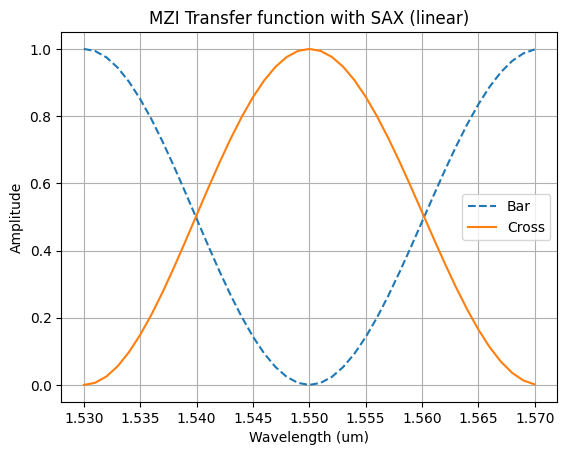

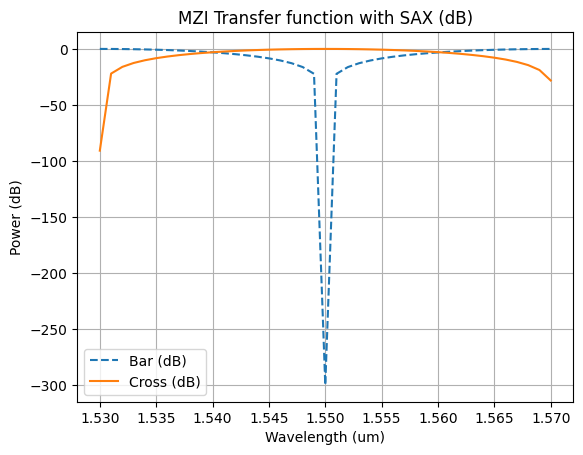

In [172]:
# Compilamos el circuito con SAX
mzi, info = sax.circuit(
    netlist=mzi_netlist, 
    models={"waveguide": waveguide, "coupler": coupler}
)

# Parámetros del modelo
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t') # SOI cross-section

wvl_sweep = SOI[:, 0]
neff_top = SOI[:, 3] # neff TE mode   # Tiene configuración balanceada, es decir, con el mismo ancho (mismo índice efectivo) para la guía superior e inferior
neff_bot = SOI[:, 3] # neff TE mode

# Propagation loss
alpha_top = 0 # Sin pérdidas [dB/um]
alpha_bot = 0 # Sin pérdidas [dB/um]

# Path length
L_top = L_top # µm (longitud del brazo corto)
L_bot = L_bot_S1 # Longitud del brazo largo para S1

# Coupling constant
K_in = 0.5 # Acoplamiento 50:50
K_out = 0.5


# Ejecutamos el modelo del MZI
mzi_circuit = mzi(wl=wvl_sweep,
    coup_in = {"coupling": K_in},
    wg_bot={"length": L_bot, "neff": neff_bot, "loss": alpha_bot},
    wg_top={"length": L_top, "neff": neff_top, "loss": alpha_top},
    coup_out = {"coupling": K_out} )

H00 = mzi_circuit["in0", "out0"] # Transmisión directa (Bar) entrada in0
H10 = mzi_circuit["in0", "out1"] # Transmisión cruzada (Cross) entrada in0
H01 = mzi_circuit["in1", "out0"] # Transmisión cruzada (Cross) entrada in1
H11 = mzi_circuit["in1", "out1"] # Transmisión directa (Bar) entrada in1

H00_dB = 10 * jnp.log10(jnp.abs(H00)**2)
H10_dB = 10 * jnp.log10(jnp.abs(H10)**2)
H01_dB = 10 * jnp.log10(jnp.abs(H01)**2)
H11_dB = 10 * jnp.log10(jnp.abs(H11)**2)

# Plot
plt.figure()
plt.plot(wvl_sweep, np.abs(H00)**2, linestyle='--', label='Bar')
plt.plot(wvl_sweep, np.abs(H10)**2, linestyle='-', label='Cross')
plt.xlabel('Wavelength (um)')
plt.ylabel('Amplitude')
plt.title('MZI Transfer function with SAX (linear)')
plt.legend()
plt.grid(True)

plt.figure()
plt.plot(wvl_sweep, H00_dB, linestyle='--', label='Bar (dB)')
plt.plot(wvl_sweep, H10_dB, linestyle='-', label='Cross (dB)')
plt.xlabel('Wavelength (um)')
plt.ylabel('Power (dB)')
plt.title('MZI Transfer function with SAX (dB)')
plt.legend()
plt.grid(True)
plt.show()

##### Caso usando aproximación lineal de dispersión (con ng) para longitudes de onda entre 1.5 y 1.6

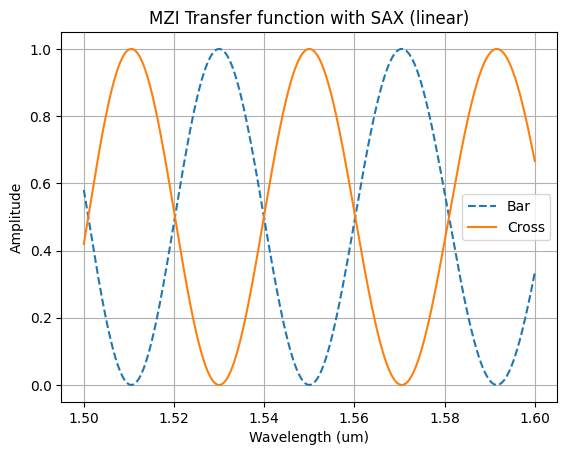

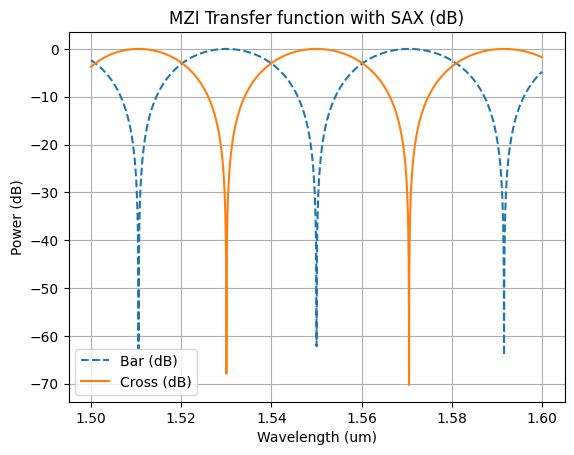

In [173]:
# Compilamos el circuito con SAX
mzi, info = sax.circuit(
    netlist=mzi_netlist, 
    models={"waveguide": waveguide_disp, "coupler": coupler}
)

# Parámetros del modelo
wvl_sweep = np.linspace(1.5, 1.6, 5000)
neff_top = n_eff_TE # Configuración balanceada. Es decir, con el mismo ancho (mismo índice efectivo) para la guía superior e inferior
neff_bot = n_eff_TE
ng_top = n_g_TE 
ng_bot = n_g_TE

# Propagation loss
alpha_top = 0 # Sin pérdidas [dB/um]
alpha_bot = 0 

# Path length
L_top = L_top # µm (longitud del brazo corto)
L_bot = L_bot_S1 # Longitud del brazo largo para S1

# Coupling constant
K_in = 0.5 # Acoplamiento 50:50
K_out = 0.5


# Ejecutamos el modelo del MZI
mzi_circuit = mzi(wl=wvl_sweep,
    coup_in = {"coupling": K_in},
    wg_top={"length": L_bot, "neff_1550": neff_bot, "ng_1550": ng_bot},
    wg_bot={"length": L_top, "neff_1550": neff_top, "ng_1550": ng_top},
    coup_out = {"coupling": K_out} )

H00 = mzi_circuit["in0", "out0"] # Transmisión directa (Bar) entrada in0
H10 = mzi_circuit["in0", "out1"] # Transmisión cruzada (Cross) entrada in0
H01 = mzi_circuit["in1", "out0"] # Transmisión cruzada (Cross) entrada in1
H11 = mzi_circuit["in1", "out1"] # Transmisión directa (Bar) entrada in1

H00_dB = 10 * jnp.log10(jnp.abs(H00)**2)
H10_dB = 10 * jnp.log10(jnp.abs(H10)**2)
H01_dB = 10 * jnp.log10(jnp.abs(H01)**2)
H11_dB = 10 * jnp.log10(jnp.abs(H11)**2)

# Plot
plt.figure()
plt.plot(wvl_sweep, np.abs(H00)**2, linestyle='--', label='Bar')
plt.plot(wvl_sweep, np.abs(H10)**2, linestyle='-', label='Cross')
plt.xlabel('Wavelength (um)')
plt.ylabel('Amplitude')
plt.title('MZI Transfer function with SAX (linear)')
plt.legend()
plt.grid(True)

plt.figure()
plt.plot(wvl_sweep, H00_dB, linestyle='--', label='Bar (dB)')
plt.plot(wvl_sweep, H10_dB, linestyle='-', label='Cross (dB)')
plt.xlabel('Wavelength (um)')
plt.ylabel('Power (dB)')
plt.title('MZI Transfer function with SAX (dB)')
plt.legend()
plt.grid(True)
plt.show()

### 3.5. Create SAX model connecting multiple MZIs in series using the designed directional couplers

### 3.6. Validate spectral alignment of outputs (Achieve transmission spectrum as shown in Figure 6(a))

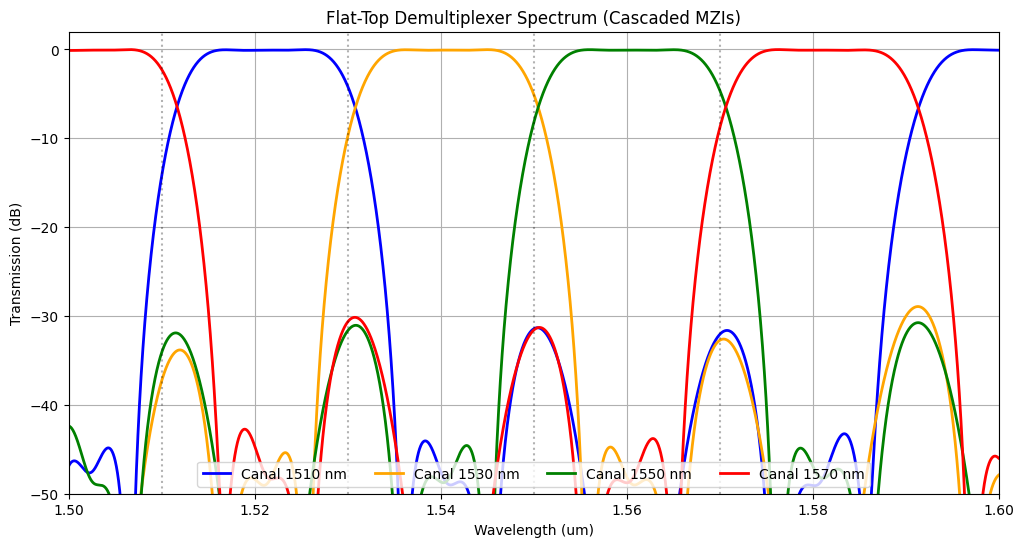

In [174]:
lambda_0 = 1.55 # Longitud de onda central

neff = n_eff_TE 
ng = n_g_TE   

# 1. CÁLCULO FÍSICO DE DELAY LINES

FSR_S1 = 0.04  # FSR requerido para la etapa S1
FSR_S2 = 0.08  # FSR requerido para la etapa S2
  
dL_S1 = (lambda_0**2) / (ng * FSR_S1)
dL_S2 = (lambda_0**2) / (ng * FSR_S2)
  
L2_S1 = L_top  # Brazo corto base para S1
L1_S1 = L2_S1 + dL_S1  # Brazo largo largo para S1
L2_S2 = L_top  # Brazo corto base para S2
L1_S2 = L2_S2 + dL_S2  # Brazo largo largo para S2

# Desfases Ópticos (pi y 0.5*pi)
L_pi = lambda_0 / (2 * neff)  # Longitud extra para un desfase de pi
L_half_pi = 0.5 * L_pi  # Longitud extra para un desfase de pi/2


# 2. DEFINICIÓN DE MODELOS BASE PARA SAX (mediante WRAPPERS)

# Acopladores Direccionales
def c_50(): return coupler(coupling=0.50)
def c_30(): return coupler(coupling=0.30)
def c_23(): return coupler(coupling=0.23)
def c_17(): return coupler(coupling=0.17)
def c_05(): return coupler(coupling=0.05)

# Guías S1 (FSR = 40 nm)
def wg_L1_S1(wl=1.55): return waveguide_disp(wl=wl, wvl_center=lambda_0, length=L1_S1, neff_1550=neff, ng_1550=ng)
def wg_L2_S1(wl=1.55): return waveguide_disp(wl=wl, wvl_center=lambda_0, length=L2_S1, neff_1550=neff, ng_1550=ng)
def wg_2L1_S1(wl=1.55): return waveguide_disp(wl=wl, wvl_center=lambda_0, length=2*L1_S1, neff_1550=neff, ng_1550=ng)
def wg_2L2_S1(wl=1.55): return waveguide_disp(wl=wl, wvl_center=lambda_0, length=2*L2_S1, neff_1550=neff, ng_1550=ng)
def wg_2L1_pi_S1(wl=1.55): return waveguide_disp(wl=wl, wvl_center=lambda_0, length=2*L1_S1 + L_pi, neff_1550=neff, ng_1550=ng)

# Guías S2 NORMAL (FSR = 80 nm)
def wg_L1_S2(wl=1.55): return waveguide_disp(wl=wl, wvl_center=lambda_0, length=L1_S2, neff_1550=neff, ng_1550=ng)
def wg_2L1_S2(wl=1.55): return waveguide_disp(wl=wl, wvl_center=lambda_0, length=2*L1_S2, neff_1550=neff, ng_1550=ng)
def wg_L2_S2(wl=1.55): return waveguide_disp(wl=wl, wvl_center=lambda_0, length=L2_S2, neff_1550=neff, ng_1550=ng)
def wg_2L2_S2(wl=1.55): return waveguide_disp(wl=wl, wvl_center=lambda_0, length=2*L2_S2, neff_1550=neff, ng_1550=ng)

# Guías S2 SHIFTED (Desplazadas para centrar los canales 1530 y 1570)
def wg_L1_shift_S2(wl=1.55): return waveguide_disp(wl=wl, wvl_center=lambda_0, length=L1_S2 + L_half_pi, neff_1550=neff, ng_1550=ng)
def wg_2L1_shift_S2(wl=1.55): return waveguide_disp(wl=wl, wvl_center=lambda_0, length=2*L1_S2 + 2*L_half_pi, neff_1550=neff, ng_1550=ng)

# Diccionario de modelos base para SAX
base_models = {
    "c_50": c_50, "c_30": c_30, "c_23": c_23, "c_17": c_17, "c_05": c_05,
    "wg_L1_S1": wg_L1_S1, "wg_L2_S1": wg_L2_S1, "wg_2L1_S1": wg_2L1_S1, "wg_2L2_S1": wg_2L2_S1, "wg_2L1_pi_S1": wg_2L1_pi_S1,
    "wg_L1_S2": wg_L1_S2, "wg_L2_S2": wg_L2_S2, "wg_2L1_S2": wg_2L1_S2, "wg_2L2_S2": wg_2L2_S2,
    "wg_L1_shift_S2": wg_L1_shift_S2, "wg_2L1_shift_S2": wg_2L1_shift_S2
}

# 3. NETLISTS DE LOS BLOQUES S1 y S2

# Bloque S1 (Maneja FSR = 40 nm)
s1_netlist = {
    "instances": {
        "c1": "c_50", "c2": "c_17", "c3": "c_23", "c4": "c_05",
        "wg_top_1": "wg_L1_S1",  "wg_bot_1": "wg_L2_S1",
        "wg_top_2": "wg_2L2_S1", "wg_bot_2": "wg_2L1_S1",
        "wg_top_3": "wg_2L2_S1", "wg_bot_3": "wg_2L1_pi_S1",
    },
    "connections": {
        "c1,out0": "wg_top_1,in0", "c1,out1": "wg_bot_1,in0", 
        "wg_top_1,out0": "c2,in0", "wg_bot_1,out0": "c2,in1",
        
        "c2,out0": "wg_top_2,in0", "c2,out1": "wg_bot_2,in0", 
        "wg_top_2,out0": "c3,in0", "wg_bot_2,out0": "c3,in1",
        
        "c3,out0": "wg_top_3,in0", "c3,out1": "wg_bot_3,in0", 
        "wg_top_3,out0": "c4,in0", "wg_bot_3,out0": "c4,in1",
    },
    "ports": {"in_top": "c1,in0", "in_bot": "c1,in1", "out_top": "c4,out0", "out_bot": "c4,out1"}
}
S1_model, info = sax.circuit(netlist=s1_netlist, models=base_models)


# Bloque S2 NORMAL
s2_norm_netlist = {
    "instances": {
        "c1": "c_50", "c2": "c_30", "c3": "c_05",
        "wg_top_1": "wg_L1_S2",  "wg_bot_1": "wg_L2_S2",
        "wg_top_2": "wg_2L2_S2", "wg_bot_2": "wg_2L1_S2",
    },
    "connections": {
        "c1,out0": "wg_top_1,in0", "c1,out1": "wg_bot_1,in0", 
        "wg_top_1,out0": "c2,in0", "wg_bot_1,out0": "c2,in1",
        
        "c2,out0": "wg_top_2,in0", "c2,out1": "wg_bot_2,in0", 
        "wg_top_2,out0": "c3,in0", "wg_bot_2,out0": "c3,in1",
    },
    "ports": {"in_top": "c1,in0", "in_bot": "c1,in1", "out_top": "c3,out0", "out_bot": "c3,out1"}
}
S2_norm_model, info = sax.circuit(netlist=s2_norm_netlist, models=base_models)


# Bloque S2 SHIFTED
s2_shift_netlist = {
    "instances": {
        "c1": "c_50", "c2": "c_30", "c3": "c_05",
        "wg_top_1": "wg_L1_shift_S2", "wg_bot_1": "wg_L2_S2",
        "wg_top_2": "wg_2L2_S2", "wg_bot_2": "wg_2L1_shift_S2",
    },
    "connections": {
        "c1,out0": "wg_top_1,in0", "c1,out1": "wg_bot_1,in0", 
        "wg_top_1,out0": "c2,in0", "wg_bot_1,out0": "c2,in1",
        
        "c2,out0": "wg_top_2,in0", "c2,out1": "wg_bot_2,in0", 
        "wg_top_2,out0": "c3,in0", "wg_bot_2,out0": "c3,in1",
    },
    "ports": {"in_top": "c1,in0", "in_bot": "c1,in1", "out_top": "c3,out0", "out_bot": "c3,out1"}
}
S2_shift_model, info = sax.circuit(netlist=s2_shift_netlist, models=base_models)


# 4. RUTEO FÍSICO EXACTO DEL ÁRBOL DEMULTIPLEXOR

tree_netlist = {
    "instances": {
        "s1_1": "S1", "s1_2": "S1", "s1_3": "S1",
        "s2_1_n": "S2_norm", "s2_3_n": "S2_norm", "s2_4_n": "S2_norm",
        "s2_2_s": "S2_shift", "s2_5_s": "S2_shift", "s2_6_s": "S2_shift"
    },
    "connections": {
        # RAMA SUPERIOR (Maneja 1510 y 1550, usa los bloques normales)
        "s1_1,out_top": "s1_2,in_bot",
        "s1_2,out_top": "s2_1_n,in_bot",
        "s2_1_n,out_top": "s2_3_n,in_bot",     
        "s2_1_n,out_bot": "s2_4_n,in_top",   

        # RAMA INFERIOR (Maneja 1530 y 1570, usa los bloques shifted)
        "s1_1,out_bot": "s1_3,in_bot",
        "s1_3,out_bot": "s2_2_s,in_top",
        "s2_2_s,out_top": "s2_5_s,in_bot",   
        "s2_2_s,out_bot": "s2_6_s,in_top",
    },
    "ports": {
        "in_main": "s1_1,in_bot",
        "out_1510": "s2_3_n,out_top",  
        "out_1550": "s2_4_n,out_top",  
        "out_1570": "s2_5_s,out_bot",    
        "out_1530": "s2_6_s,out_bot",  
  
    }
}

# Compilamos el circuito final inyectando los sub-modelos ya ensamblados
tree_circuit, info = sax.circuit(
    netlist=tree_netlist, 
    models={"S1": S1_model, "S2_norm": S2_norm_model, "S2_shift": S2_shift_model}
)


# 5. SIMULACIÓN Y VISUALIZACIÓN

# Generamos el array de longitudes de onda
wvl_sweep = jnp.linspace(1.50, 1.60, 5000)

# Evaluamos el circuito completo pasándole únicamente la longitud de onda
S_tree = tree_circuit(wl=wvl_sweep)

# Extracción de la potencia en dB para cada puerto de salida
T_1510 = 10 * jnp.log10(jnp.abs(S_tree["in_main", "out_1510"])**2)
T_1530 = 10 * jnp.log10(jnp.abs(S_tree["in_main", "out_1530"])**2)
T_1550 = 10 * jnp.log10(jnp.abs(S_tree["in_main", "out_1550"])**2)
T_1570 = 10 * jnp.log10(jnp.abs(S_tree["in_main", "out_1570"])**2)

# Gráfica
plt.figure(figsize=(12, 6))
plt.plot(wvl_sweep, T_1510, label="Canal 1510 nm", color='blue', linewidth=2)
plt.plot(wvl_sweep, T_1530, label="Canal 1530 nm", color='orange', linewidth=2)
plt.plot(wvl_sweep, T_1550, label="Canal 1550 nm", color='green', linewidth=2)
plt.plot(wvl_sweep, T_1570, label="Canal 1570 nm", color='red', linewidth=2)

# Líneas verticales de referencia para los canales
canales = [1.51, 1.53, 1.55, 1.57]
for c in canales:
    plt.axvline(c, color='black', alpha=0.3, linestyle=':')

plt.xlabel("Wavelength (um)")
plt.ylabel("Transmission (dB)")
plt.title("Flat-Top Demultiplexer Spectrum (Cascaded MZIs)")
plt.ylim(-50, 2)
plt.xlim(1.50, 1.60)
plt.legend(loc="lower center", ncol=4)
plt.grid(True)
plt.show()